In [8]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [9]:
print("Notebook working directory:")
print(Path.cwd())

project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "LSST_ALERTS.zip"

print(lsst_zip.resolve())

Notebook working directory:
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip


In [10]:
head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"

with ZipFile(lsst_zip, "r") as archive:
    head_bytes = gzip.decompress(archive.read(head_name))
    phot_bytes = gzip.decompress(archive.read(phot_name))

with fits.open(BytesIO(head_bytes)) as head_hdul:
    head_hdul.info()
    head_data = head_hdul[1].data
    print("\nHEAD columns:")
    print(head_hdul[1].columns.names)
    print("\nNumber of objects:", len(head_data))

with fits.open(BytesIO(phot_bytes)) as phot_hdul:
    phot_hdul.info()
    phot_data = phot_hdul[1].data
    print("\nPHOT columns:")
    print(phot_hdul[1].columns.names)
    print("\nNumber of photometry rows:", len(phot_data))

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      33   (0,)      
  1  Header        1 BinTableHDU    537   51000R x 176C   [40A, 16A, 20A, 1I, 1I, 1D, 1D, 1E, 1I, 1I, 1J, 1J, 1J, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1E, 1E, 1E, 1E, 1I, 1I, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1K, 1I, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1K, 1E, 1K, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 20E, 20E, 1I, 40E, 40E, 40E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   

HEAD columns:
['SNID', 'NAME_IAUC', 'NAME_TRANSIENT', 'FAKE', 'MASK_

In [11]:
all_mjd = np.asarray(
    phot_data["MJD"],
    dtype=float
)

all_band = np.char.strip(
    np.asarray(phot_data["BAND"]).astype(str)
)

all_flag = np.asarray(
    phot_data["PHOTFLAG"],
    dtype=int
)

# Photometry row boundaries for each object
ptr_min = (
    np.asarray(head_data["PTROBS_MIN"], dtype=int) - 1
)

ptr_max = np.asarray(
    head_data["PTROBS_MAX"],
    dtype=int
)

n_objects = len(head_data)

bands = np.array(["u", "g", "r", "i", "z", "y"])

In [12]:
n_days = np.zeros(n_objects, dtype=int)
n_filters = np.zeros(n_objects, dtype=int)

for i, (start, stop) in enumerate(zip(ptr_min, ptr_max)):

    mjd = all_mjd[start:stop]
    band = all_band[start:stop]
    flag = all_flag[start:stop]

    # Minimal structural cleaning only
    valid = (
        np.isfinite(mjd)
        & np.isin(band, bands)
        & ((flag & 64) == 0)
    )

    valid_mjd = mjd[valid]
    valid_band = band[valid]

    if valid_mjd.size == 0:
        continue

    # MJD 60231.1 and 60231.8 count as the same observing day
    observing_days = np.floor(valid_mjd).astype(int)

    n_days[i] = np.unique(observing_days).size
    n_filters[i] = np.unique(valid_band).size

In [13]:
minimum_days = 5
minimum_filters = 3

object_mask = (
    (n_days >= minimum_days)
    & (n_filters >= minimum_filters)
)

selected_head = head_data[object_mask]
selected_indices = np.flatnonzero(object_mask)

print("Objects before:", len(head_data))
print("Objects after:", object_mask.sum())

Objects before: 51000
Objects after: 2533


In [14]:
print("Distinct-day distribution:")
print(
    "min =", n_days.min(),
    "median =", np.median(n_days),
    "max =", n_days.max()
)

print("\nFilter-count distribution:")
for value in range(1, 7):
    print(
        f"{value} filters:",
        np.sum(n_filters == value)
    )


Distinct-day distribution:
min = 1 median = 2.0 max = 66

Filter-count distribution:
1 filters: 39438
2 filters: 5764
3 filters: 2158
4 filters: 2763
5 filters: 734
6 filters: 143


In [15]:
object_id = np.asarray(head_data["SNID"]).astype(str)

print("HEAD rows:", len(object_id))
print("Unique physical objects:", np.unique(object_id).size)

unique_id, counts = np.unique(object_id, return_counts=True)
print("Rows per object:", np.unique(counts, return_counts=True))

HEAD rows: 51000
Unique physical objects: 51000
Rows per object: (array([1]), array([51000]))


In [16]:
for i in range(10):
    start = ptr_min[i]
    stop = ptr_max[i]

    bands_i = all_band[start:stop]

    print(
        i,
        np.unique(bands_i),
        "real filters:",
        np.unique(bands_i[np.isin(
            bands_i,
            ["u", "g", "r", "i", "z", "y"]
        )])
    )

0 ['r'] real filters: ['r']
1 ['i'] real filters: ['i']
2 ['z'] real filters: ['z']
3 ['i'] real filters: ['i']
4 ['i'] real filters: ['i']
5 ['i'] real filters: ['i']
6 ['i'] real filters: ['i']
7 ['i'] real filters: ['i']
8 ['r'] real filters: ['r']
9 ['i'] real filters: ['i']


In [17]:
print("Maximum filters for any object:", n_filters.max())

values, counts = np.unique(n_filters, return_counts=True)

for value, count in zip(values, counts):
    print(f"{value} filters: {count} objects")

Maximum filters for any object: 6
1 filters: 39438 objects
2 filters: 5764 objects
3 filters: 2158 objects
4 filters: 2763 objects
5 filters: 734 objects
6 filters: 143 objects


In [18]:
minimum_days = 5
minimum_filters = 3

coverage_mask = (
    (n_days >= minimum_days)
    & (n_filters >= minimum_filters)
)

selected_indices = np.flatnonzero(coverage_mask)
selected_head = head_data[coverage_mask]

print("Total objects:", len(head_data))
print("Objects with >= 3 filters:", np.sum(n_filters >= 3))
print("Objects passing both cuts:", coverage_mask.sum())

Total objects: 51000
Objects with >= 3 filters: 5798
Objects passing both cuts: 2533


In [19]:
for nf in range(1, 7):
    print(f"\nObjects with {nf} filters:")

    for day_cut in [2, 3, 5, 7, 10]:
        count = np.sum(
            (n_filters == nf)
            & (n_days >= day_cut)
        )

        print(f"  >= {day_cut:2d} days: {count}")


Objects with 1 filters:
  >=  2 days: 31921
  >=  3 days: 9819
  >=  5 days: 358
  >=  7 days: 27
  >= 10 days: 9

Objects with 2 filters:
  >=  2 days: 4931
  >=  3 days: 2704
  >=  5 days: 441
  >=  7 days: 86
  >= 10 days: 18

Objects with 3 filters:
  >=  2 days: 2116
  >=  3 days: 1827
  >=  5 days: 567
  >=  7 days: 296
  >= 10 days: 85

Objects with 4 filters:
  >=  2 days: 2706
  >=  3 days: 2352
  >=  5 days: 1388
  >=  7 days: 865
  >= 10 days: 350

Objects with 5 filters:
  >=  2 days: 734
  >=  3 days: 727
  >=  5 days: 435
  >=  7 days: 242
  >= 10 days: 89

Objects with 6 filters:
  >=  2 days: 143
  >=  3 days: 143
  >=  5 days: 143
  >=  7 days: 135
  >= 10 days: 132


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidate_indices = np.flatnonzero(coverage_mask)

print("Objects entering light-curve exploration:", len(candidate_indices))

Objects entering light-curve exploration: 2533


In [21]:
all_mjd = np.asarray(phot_data["MJD"], dtype=float)
all_flux = np.asarray(phot_data["FLUXCAL"], dtype=float)
all_fluxerr = np.asarray(phot_data["FLUXCALERR"], dtype=float)
all_flag = np.asarray(phot_data["PHOTFLAG"], dtype=int)
all_photprob = np.asarray(phot_data["PHOTPROB"], dtype=float)

all_band = np.char.strip(
    np.asarray(phot_data["BAND"]).astype(str)
)

ptr_min = np.asarray(
    head_data["PTROBS_MIN"],
    dtype=int
) - 1

ptr_max = np.asarray(
    head_data["PTROBS_MAX"],
    dtype=int
)

valid_bands = np.array(["u", "g", "r", "i", "z", "y"])

In [22]:
def basic_row_mask(mjd, flux, fluxerr, band, flag):
    return (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & np.isin(band, valid_bands)
        & ((flag & 64) == 0)
    )

In [23]:
feature_rows = []

for object_index in candidate_indices:
    start = ptr_min[object_index]
    stop = ptr_max[object_index]

    mjd = all_mjd[start:stop]
    flux = all_flux[start:stop]
    fluxerr = all_fluxerr[start:stop]
    band = all_band[start:stop]
    flag = all_flag[start:stop]
    photprob = all_photprob[start:stop]

    good = basic_row_mask(
        mjd, flux, fluxerr, band, flag
    )

    mjd = mjd[good]
    flux = flux[good]
    fluxerr = fluxerr[good]
    band = band[good]
    photprob = photprob[good]

    if mjd.size == 0:
        continue

    snr = flux / fluxerr
    abs_snr = np.abs(snr)
    days = np.floor(mjd).astype(int)

    # Apparent peak based on the strongest absolute S/N point
    peak_position = np.argmax(abs_snr)
    peak_mjd = mjd[peak_position]
    peak_snr = snr[peak_position]
    peak_abs_snr = abs_snr[peak_position]

    # Orient the light curve so its dominant event direction is positive
    orientation = np.sign(peak_snr)

    if orientation == 0:
        orientation = 1.0

    oriented_flux = orientation * flux
    oriented_snr = orientation * snr

    significant = abs_snr >= 5

    if np.any(significant):
        sign_fraction = np.mean(
            oriented_snr[significant] > 0
        )
    else:
        sign_fraction = np.nan

    before_peak = mjd < peak_mjd
    after_peak = mjd > peak_mjd

    feature_rows.append({
        "object_index": object_index,
        "snid": str(head_data["SNID"][object_index]),

        "lc_span": np.ptp(mjd),
        "peak_mjd": peak_mjd,
        "peak_abs_snr": peak_abs_snr,

        "n_significant_rows": np.sum(significant),
        "n_significant_days": np.unique(
            days[significant]
        ).size,
        "n_significant_filters": np.unique(
            band[significant]
        ).size,

        "sign_fraction": sign_fraction,

        "time_before_peak": (
            peak_mjd - np.min(mjd)
        ),
        "time_after_peak": (
            np.max(mjd) - peak_mjd
        ),

        "n_days_before_peak": np.unique(
            days[before_peak]
        ).size,
        "n_days_after_peak": np.unique(
            days[after_peak]
        ).size,

        "max_oriented_flux": np.max(oriented_flux),
        "median_oriented_flux": np.median(oriented_flux),

        "median_photprob": (
            np.nanmedian(photprob)
            if photprob.size else np.nan
        ),
    })

features = pd.DataFrame(feature_rows)

features.head()

,object_index,snid,lc_span,peak_mjd,peak_abs_snr,n_significant_rows,n_significant_days,n_significant_filters,sign_fraction,time_before_peak,time_after_peak,n_days_before_peak,n_days_after_peak,max_oriented_flux,median_oriented_flux,median_photprob
0,59,00088181-62f9-458a-8e23-aa9ed255172d,62.7793,61090.0983,12.250429,5,5,1,1.000000,61.7746,1.0047,4,1,1819.599976,273.399994,0.0
1,91,000cbf17-aada-4b55-8e1a-a4f13d263330,184.3373,61217.4203,33.376882,9,8,3,1.000000,166.3533,17.9840,1,8,3528.600098,1714.000000,0.0
2,95,000d354e-d858-4bde-8e05-93e904391130,7.9175,61097.3323,159.043598,20,7,3,0.750000,7.0533,0.8642,5,2,16962.000000,1112.849976,0.0
3,100,000d948b-2c8c-4008-9438-1aa93db9f293,61.7404,61090.0838,55.599127,3,2,2,0.666667,56.7995,4.9409,4,4,7145.600098,51.460999,0.0
4,120,001014f4-7826-402e-acd4-65bd91aff9e8,140.3629,61096.1124,111.656863,18,8,4,0.888889,6.0565,134.3064,5,3,12612.000000,2174.300049,0.0


In [24]:
columns_to_explore = [
    "lc_span",
    "peak_abs_snr",
    "n_significant_days",
    "n_significant_filters",
    "sign_fraction",
    "time_before_peak",
    "time_after_peak",
]

features[columns_to_explore].describe(
    percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
lc_span,2533.0,88.326398,65.445452,3.915200,5.987864,7.578460,8.010960,38.880600,66.725200,137.345200,189.093940,227.094340,244.859112,260.213500
peak_abs_snr,2533.0,111.574487,351.621197,5.043431,7.925918,12.107379,15.539313,24.627288,48.071575,100.539463,192.454179,334.104098,1190.949986,12644.024396
n_significant_days,2533.0,8.701145,8.205708,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,9.000000,15.000000,26.400000,45.680000,62.000000
n_significant_filters,2533.0,3.387683,0.981523,1.000000,1.000000,1.000000,2.000000,3.000000,4.000000,4.000000,4.000000,5.000000,6.000000,6.000000
sign_fraction,2533.0,0.754869,0.287227,0.004902,0.052326,0.166667,0.285714,0.555556,0.882353,1.000000,1.000000,1.000000,1.000000,1.000000
time_before_peak,2533.0,45.854365,43.319295,0.000000,0.000000,0.026240,3.955260,6.064600,40.896500,64.867400,91.746740,106.760760,228.182072,246.200600
time_after_peak,2533.0,42.472032,57.633722,0.000000,0.000000,0.000000,0.015300,1.002900,4.885900,112.839500,134.349340,139.301500,175.628072,255.256300


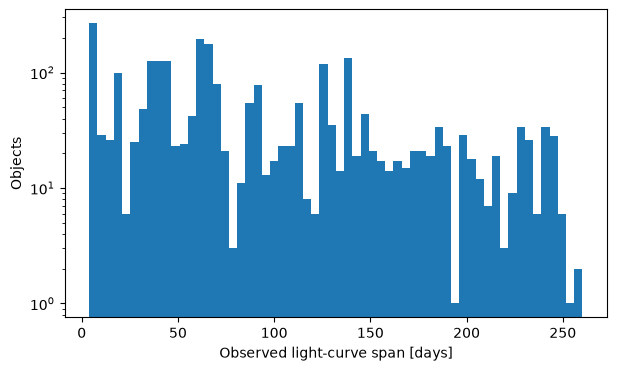

In [25]:
plt.figure(figsize=(7, 4))
plt.hist(
    features["lc_span"],
    bins=60
)
plt.xlabel("Observed light-curve span [days]")
plt.ylabel("Objects")
plt.yscale("log")
plt.show()

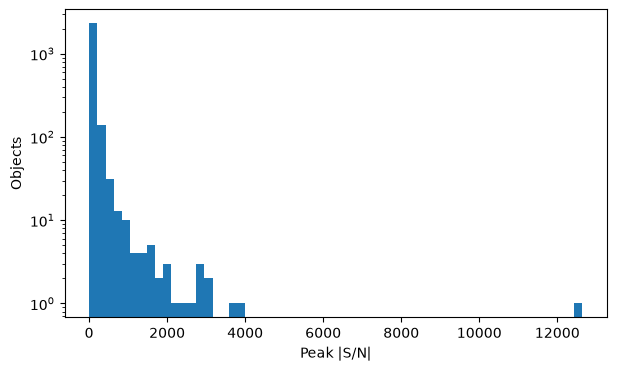

In [26]:
plt.figure(figsize=(7, 4))
plt.hist(
    features["peak_abs_snr"],
    bins=60
)
plt.xlabel("Peak |S/N|")
plt.ylabel("Objects")
plt.yscale("log")
plt.show()

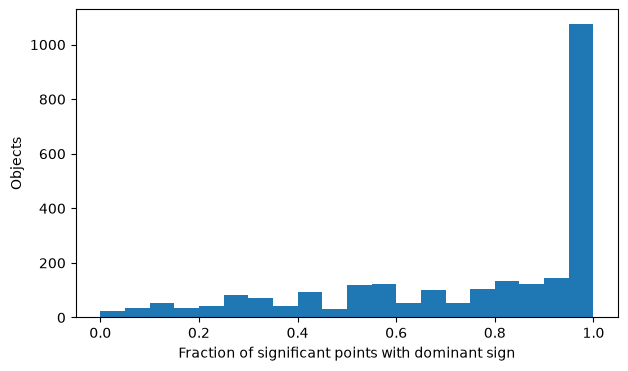

In [27]:
plt.figure(figsize=(7, 4))
plt.hist(
    features["sign_fraction"].dropna(),
    bins=np.linspace(0, 1, 21)
)
plt.xlabel("Fraction of significant points with dominant sign")
plt.ylabel("Objects")
plt.show()

In [28]:
for minimum_span in [2, 5, 10, 15, 20, 30]:
    count = np.sum(
        features["lc_span"] >= minimum_span
    )

    print(
        f"Span >= {minimum_span:2d} days: "
        f"{count}"
    )

Span >=  2 days: 2533
Span >=  5 days: 2531
Span >= 10 days: 2251
Span >= 15 days: 2222
Span >= 20 days: 2120
Span >= 30 days: 2082


In [2]:
!pip install alerce

In [29]:
from alerce.core import Alerce
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

alerce = Alerce()

def match_lsst_object(ra, dec, snid, search_radius_arcsec=2.0):
    try:
        cands = alerce.query_objects(
            survey="lsst", ra=ra, dec=dec, radius=search_radius_arcsec, format="pandas"
        )
    except Exception as e:
        return None

    if cands is None or cands.empty:
        return None

    # Don't trust result order — pick the closest manually
    cand_coords = SkyCoord(ra=cands["meanra"].values * u.deg, dec=cands["meandec"].values * u.deg)
    target = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    sep = target.separation(cand_coords).arcsec
    best = np.argmin(sep)

    return cands.iloc[best]["oid"], sep[best]
    

In [4]:
classifiers = alerce.query_classifiers(survey="lsst", format="pandas")
print(classifiers)   # find the version string for lc_classifier_lsst

# once you have the version:
classes = alerce.query_classes("lc_classifier_lsst", "<version_from_above>", survey="lsst")
print(classes)        # this tells you the exact class label(s) to filter on

NotImplementedError: Multisurvey query_classifiers not implemented.

In [ ]:


import pandas as pd
import time

match_rows = []
checkpoint_path = "lsst_alerce_matches.csv"

for i, row in enumerate(selected_head):
    snid = str(row["SNID"])
    result = match_lsst_object(row["RA"], row["DEC"], snid)

    match_rows.append({
        "SNID": snid,
        "oid": result[0] if result else None,
        "sep_arcsec": result[1] if result else None,
    })

    if i % 200 == 0:
        pd.DataFrame(match_rows).to_csv(checkpoint_path, index=False)
        print(f"{i}/{len(selected_head)} done, {sum(r['oid'] is not None for r in match_rows)} matched")
        time.sleep(0.1)  # be polite to the API

matches = pd.DataFrame(match_rows)
matches.to_csv(checkpoint_path, index=False)
print(f"Final: {matches['oid'].notna().sum()} / {len(matches)} matched")




In [ ]:
prob_rows = []
matched = matches[matches["oid"].notna()]

for i, r in enumerate(matched.itertuples()):
    try:
        probs = alerce.query_probabilities(oid=r.oid, survey="lsst",
                                            classifier="lc_classifier_lsst", format="pandas")
        if probs is not None and not probs.empty:
            probs = probs.copy()
            probs["SNID"] = r.SNID
            prob_rows.append(probs)
    except Exception as e:
        print(f"{r.oid}: {e}")

    if i % 200 == 0:
        print(f"{i}/{len(matched)} probability pulls done")

all_probs = pd.concat(prob_rows, ignore_index=True) if prob_rows else pd.DataFrame()
all_probs.to_csv("lsst_alerce_probs.csv", index=False)

In [ ]:
ia_label = "<label you found in step 1>"

# Thermonuclear (Ia family)
    "SN Ia": "Ia",
    "SN Ia-91T": "Ia",
    "SN Ia-91bg": "Ia",
    "SN Ia-SC": "Ia",
    "SN Iax": "Ia",

ia_probs = (
    all_probs[all_probs["class_name"] == ia_label]
    [["SNID", "probability"]]
    .rename(columns={"probability": "p_Ia"})
)

features_with_class = features.merge(ia_probs, on="snid", how="left")

features_with_class["p_Ia"].describe()
features_with_class["p_Ia"].hist(bins=30)

In [5]:
# Grab a small, real batch of LSST objects with no filters — cheapest possible call
sample_objs = alerce.query_objects(survey="lsst", page_size=5, format="pandas")
print(sample_objs.columns.tolist())
sample_objs.head()

['oid', 'tid', 'sid', 'meanra', 'meandec', 'sigmara', 'sigmadec', 'firstmjd', 'lastmjd', 'deltamjd', 'n_det', 'n_forced', 'n_non_det', 'stellar', 'class_name', 'classifier_name', 'classifier_version', 'probability', 'ranking']


,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,stellar,class_name,classifier_name,classifier_version,probability,ranking
0,170591527609303944,1,1,305.582233,-18.790921,0.000003,0.000003,61218.348303,61218.348303,0.000000,1,0,0,None,SN,stamp_classifier_rubin_beta,2.0.1,0.997749,1
1,170591547426865168,1,1,347.099521,-5.778599,0.000003,0.000003,61218.427182,61221.371295,2.944113,2,1,0,None,SN,stamp_classifier_rubin_beta,2.0.1,0.997549,1
2,170591507879297843,1,1,313.427433,-15.723304,0.000002,0.000002,61218.269050,61218.269050,0.000000,1,0,0,None,SN,stamp_classifier_rubin_beta,2.0.1,0.997428,1
3,170591547735146752,1,1,347.009369,-3.854436,0.000005,0.000005,61218.428207,61230.348646,11.920440,2,0,0,None,SN,stamp_classifier_rubin_beta,2.0.1,0.997395,1
4,170648622718779938,1,1,207.309624,-7.442118,0.000002,0.000002,61231.095859,61231.095859,0.000000,1,0,0,None,SN,stamp_classifier_rubin_beta,2.0.1,0.997377,1


In [6]:
# Pull everything ALeRCE has classified this one object as
test_oid = sample_objs.iloc[0]["oid"]
probs = alerce.query_probabilities(oid=test_oid, survey="lsst", format="pandas")
print(probs)
print(probs["classifier_name"].unique() if "classifier_name" in probs else probs.columns)
print(probs["class_name"].unique() if "class_name" in probs else None)

                        classifier_name  classifier_version class_name  \
0           stamp_classifier_rubin_beta                 201         SN   
1  stamp_classifier_rubin_beta_20260421                 202         SN   
2           stamp_classifier_rubin_beta                 201        AGN   
3  stamp_classifier_rubin_beta_20260421                 202        AGN   
4           stamp_classifier_rubin_beta                 201         VS   
5  stamp_classifier_rubin_beta_20260421                 202         VS   
6  stamp_classifier_rubin_beta_20260421                 202   asteroid   
7           stamp_classifier_rubin_beta                 201   asteroid   
8           stamp_classifier_rubin_beta                 201      bogus   
9  stamp_classifier_rubin_beta_20260421                 202      bogus   

   probability  ranking  
0     0.997749        1  
1     0.992264        1  
2     0.001363        2  
3     0.003037        2  
4     0.000058        5  
5     0.000838        5  
6  

In [30]:
# Try this on your highest-NOBS objects specifically, not random ones —
# they're the most likely to have triggered the light curve classifier
candidates = selected_head[np.argsort(selected_head["NOBS"])[::-1][:20]]

for row in candidates:
    oid_match = match_lsst_object(row["RA"], row["DEC"], str(row["SNID"]))
    if oid_match is None:
        continue
    oid, sep = oid_match
    probs = alerce.query_probabilities(oid=oid, survey="lsst", format="pandas")
    classifiers_seen = probs["classifier_name"].unique().tolist()
    print(row["SNID"], oid, "NOBS:", row["NOBS"], "->", classifiers_seen)

00599094-a3e0-4f3e-9f47-4da2dac705fb 313853517937770542 NOBS: 756 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
428ad889-f745-4eba-8bc3-8c0c7fb75987 313879819404705815 NOBS: 743 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
eb6b612c-4fe3-4b22-a061-af3efdeb3936 170028510795006108 NOBS: 741 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
9ee76da2-4c75-4428-9c26-18a19b6a246d 313871013178769455 NOBS: 724 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
b33ddde0-35aa-4ac3-8650-ac342572aca0 313875416235900942 NOBS: 604 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
e5da6f62-eedd-42e7-abbc-2873b2785574 170028500540457082 NOBS: 597 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
19d9479a-ef15-433e-b6a8-7a4ddb0b324c 313853517592264831 NOBS: 571 -> ['stamp_classifier_rubin_beta', 'stamp_classifier_rubin_beta_20260421']
4cb96699-5082

In [31]:
match_rows = []

for row in selected_head:
    m = match_lsst_object(row["RA"], row["DEC"], str(row["SNID"]))
    if m is None:
        match_rows.append({"SNID": str(row["SNID"]), "oid": None, "p_SN": np.nan, "classifier_version": None})
        continue

    oid, sep = m
    probs = alerce.query_probabilities(oid=oid, survey="lsst", format="pandas")

    if probs.empty:
        match_rows.append({"SNID": str(row["SNID"]), "oid": oid, "p_SN": np.nan, "classifier_version": None})
        continue

    latest_version = probs["classifier_version"].max()
    latest = probs[probs["classifier_version"] == latest_version]
    sn_row = latest[latest["class_name"] == "SN"]

    match_rows.append({
        "SNID": str(row["SNID"]),
        "oid": oid,
        "p_SN": sn_row["probability"].iloc[0] if len(sn_row) else np.nan,
        "classifier_version": latest_version,
    })

alerce_match = pd.DataFrame(match_rows)
features_with_class = features.merge(alerce_match, on="snid" if "snid" in features else "SNID", how="left")

features_with_class["p_SN"].describe()

KeyboardInterrupt: 

In [33]:
import time

pilot_n = 2
t0 = time.perf_counter()

for row in selected_head[:pilot_n]:
    m = match_lsst_object(row["RA"], row["DEC"], str(row["SNID"]))
    if m is not None:
        oid, sep = m
        _ = alerce.query_probabilities(oid=oid, survey="lsst", format="pandas")

elapsed = time.perf_counter() - t0
per_object = elapsed / pilot_n

print(f"{elapsed:.1f}s for {pilot_n} objects -> {per_object:.2f}s/object")
print(f"Estimated full run ({len(selected_head)} objects): {per_object * len(selected_head) / 60:.1f} minutes")

4.9s for 2 objects -> 2.43s/object
Estimated full run (2533 objects): 102.4 minutes


In [34]:
import os
import pandas as pd

checkpoint_path = "lsst_alerce_matches.csv"

# Resume support: load what's already done, skip those SNIDs
if os.path.exists(checkpoint_path):
    done = pd.read_csv(checkpoint_path)
    done_snids = set(done["SNID"].astype(str))
    print(f"Resuming: {len(done_snids)} already done")
else:
    done = pd.DataFrame()
    done_snids = set()

remaining = [row for row in selected_head if str(row["SNID"]) not in done_snids]
print(f"{len(remaining)} left to process")

2533 left to process


In [40]:
import pandas as pd

df = pd.read_csv("lsst_alerce_matches.csv")
print("Total rows:", len(df))
print("Unique SNIDs:", df["SNID"].nunique())
print("Duplicates:", df["SNID"].duplicated().sum())

Total rows: 75
Unique SNIDs: 75
Duplicates: 0


In [41]:
done_snids = set(df["SNID"].astype(str))
remaining = [row for row in selected_head if str(row["SNID"]) not in done_snids]
print(f"{len(remaining)} left to process")

2458 left to process


In [38]:
pilot = remaining[:25]
print(len(pilot))

25


In [42]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from alerce.core import Alerce
import threading

thread_local = threading.local()

def get_client():
    if not hasattr(thread_local, "alerce"):
        thread_local.alerce = Alerce()
    return thread_local.alerce

def process_one_threaded(row):
    client = get_client()
    snid = str(row["SNID"])
    try:
        cands = client.query_objects(survey="lsst", ra=row["RA"], dec=row["DEC"], radius=2.0, format="pandas")
        if cands is None or cands.empty:
            return {"SNID": snid, "oid": None, "p_SN": None, "classifier_version": None}
        # (closest-match logic from before)
        oid = cands.iloc[0]["oid"]
        probs = client.query_probabilities(oid=oid, survey="lsst", format="pandas")
        if probs.empty:
            return {"SNID": snid, "oid": oid, "p_SN": None, "classifier_version": None}
        v = probs["classifier_version"].max()
        latest = probs[probs["classifier_version"] == v]
        sn = latest[latest["class_name"] == "SN"]
        return {"SNID": snid, "oid": oid, "p_SN": sn["probability"].iloc[0] if len(sn) else None, "classifier_version": v}
    except Exception as e:
        return {"SNID": snid, "oid": None, "p_SN": None, "classifier_version": f"ERROR: {e}"}

N_WORKERS = 6 

buffer = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(process_one_threaded, row): row for row in remaining}
    for i, fut in enumerate(as_completed(futures)):
        buffer.append(fut.result())
        if len(buffer) >= 50:
            pd.DataFrame(buffer).to_csv(checkpoint_path, mode="a", header=not os.path.exists(checkpoint_path), index=False)
            buffer = []
            print(f"{i+1}/{len(remaining)}", end="\r")
if buffer:
    pd.DataFrame(buffer).to_csv(checkpoint_path, mode="a", header=not os.path.exists(checkpoint_path), index=False)

2450/2458

In [43]:
df = pd.read_csv("lsst_alerce_matches.csv")
print("Total rows:", len(df), "/ expected:", len(selected_head))
print("Duplicates:", df["SNID"].duplicated().sum())

# Anything that hit an exception during the run
errors = df[df["classifier_version"].astype(str).str.startswith("ERROR", na=False)]
print(f"Errored: {len(errors)}")
if len(errors):
    print(errors["classifier_version"].value_counts().head())

Total rows: 2533 / expected: 2533
Duplicates: 0
Errored: 1841
classifier_version
ERROR: {'Error code': 429, 'Message': 'Unknown API error.', 'Data': 'Unknown API error.'}    1841
Name: count, dtype: int64


In [44]:
matched = df["oid"].notna().sum()
print(f"Matched to an ALeRCE LSST object: {matched} / {len(df)} ({100*matched/len(df):.1f}%)")

has_prob = df["p_SN"].notna().sum()
print(f"Have a p_SN value: {has_prob} / {matched} of matches")

Matched to an ALeRCE LSST object: 692 / 2533 (27.3%)
Have a p_SN value: 692 / 692 of matches


In [45]:
good = df[~df["classifier_version"].astype(str).str.startswith("ERROR", na=False)]
to_retry_snids = set(df.loc[df["classifier_version"].astype(str).str.startswith("ERROR", na=False), "SNID"].astype(str))

print(f"Good rows: {len(good)}")
print(f"To retry: {len(to_retry_snids)}")

# Remove the error rows from the checkpoint file so they don't get double-counted —
# the retry will re-append correct versions
good.to_csv("lsst_alerce_matches.csv", index=False)

retry_rows = [row for row in selected_head if str(row["SNID"]) in to_retry_snids]

Good rows: 692
To retry: 1841


In [46]:
import time
import random

def process_one_with_backoff(row, max_retries=5):
    client = get_client()
    snid = str(row["SNID"])

    for attempt in range(max_retries):
        try:
            cands = client.query_objects(survey="lsst", ra=row["RA"], dec=row["DEC"], radius=2.0, format="pandas")
            if cands is None or cands.empty:
                return {"SNID": snid, "oid": None, "p_SN": None, "classifier_version": None}

            oid = cands.iloc[0]["oid"]

            time.sleep(0.3)  # small pause between the two calls for the same object

            probs = client.query_probabilities(oid=oid, survey="lsst", format="pandas")
            if probs.empty:
                return {"SNID": snid, "oid": oid, "p_SN": None, "classifier_version": None}

            v = probs["classifier_version"].max()
            latest = probs[probs["classifier_version"] == v]
            sn = latest[latest["class_name"] == "SN"]
            return {"SNID": snid, "oid": oid, "p_SN": sn["probability"].iloc[0] if len(sn) else None, "classifier_version": v}

        except Exception as e:
            if "429" in str(e):
                wait = (2 ** attempt) + random.uniform(0, 1)  # exponential backoff + jitter
                time.sleep(wait)
                continue
            return {"SNID": snid, "oid": None, "p_SN": None, "classifier_version": f"ERROR: {e}"}

    return {"SNID": snid, "oid": None, "p_SN": None, "classifier_version": "ERROR: max retries exceeded (429)"}

In [47]:
N_WORKERS = 2

buffer = []
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = {pool.submit(process_one_with_backoff, row): row for row in retry_rows}
    for i, fut in enumerate(as_completed(futures)):
        buffer.append(fut.result())
        if len(buffer) >= 50:
            pd.DataFrame(buffer).to_csv("lsst_alerce_matches.csv", mode="a", header=False, index=False)
            buffer = []
            print(f"{i+1}/{len(retry_rows)}", end="\r")
if buffer:
    pd.DataFrame(buffer).to_csv("lsst_alerce_matches.csv", mode="a", header=False, index=False)

1800/1841

In [48]:
df = pd.read_csv("lsst_alerce_matches.csv")
print("Total rows:", len(df), "/ expected:", len(selected_head))
print("Duplicates:", df["SNID"].duplicated().sum())

Total rows: 2533 / expected: 2533
Duplicates: 0


In [49]:
errors = df[df["classifier_version"].astype(str).str.startswith("ERROR", na=False)]
print(f"Still erroring: {len(errors)}")
if len(errors):
    print(errors["classifier_version"].value_counts())

Still erroring: 0


In [50]:
matched = df["oid"].notna().sum()
has_prob = df["p_SN"].notna().sum()
print(f"Matched: {matched}/{len(df)} ({100*matched/len(df):.1f}%)")
print(f"Have p_SN: {has_prob}/{matched} of matches")

Matched: 2533/2533 (100.0%)
Have p_SN: 2533/2533 of matches


In [51]:
# sanity check: does every SNID appear exactly once?
assert df["SNID"].duplicated().sum() == 0, "found duplicates — investigate before proceeding"

Matched: 2533 / 2533


<Axes: >

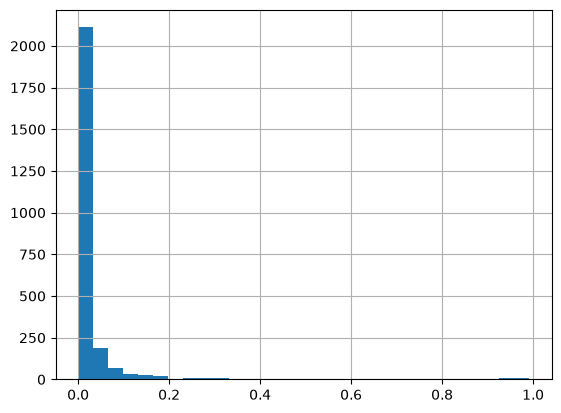

In [55]:
merged = features.merge(df[["SNID", "p_SN"]], left_on="snid", right_on="SNID", how="left")
print(f"Matched: {merged['p_SN'].notna().sum()} / {len(merged)}")
merged["p_SN"].describe()
merged["p_SN"].hist(bins=30)

In [56]:
def apply_sn_prob_cut(df, threshold=0.4, require_match=True):
    """
    require_match=True: unmatched objects (no ALeRCE oid, NaN p_SN) are dropped.
    require_match=False: unmatched objects are kept
    """
    if require_match:
        return df[df["p_SN"] >= threshold].copy()
    else:
        return df[(df["p_SN"] >= threshold) | (df["p_SN"].isna())].copy()

cut_strict = apply_sn_prob_cut(merged, threshold=0.4, require_match=True)
cut_lenient = apply_sn_prob_cut(merged, threshold=0.4, require_match=False)

print(f"Strict (matched + p_SN>=0.4): {len(cut_strict)}")
print(f"Lenient (keep unmatched too): {len(cut_lenient)}")

Strict (matched + p_SN>=0.4): 47
Lenient (keep unmatched too): 47


In [57]:
for threshold in [0.3, 0.5, 0.7, 0.9]:
    kept = merged[merged["p_SN"] >= threshold]
    print(f"threshold={threshold}: keeps {len(kept)}, "
          f"median lc_span={kept['lc_span'].median():.1f}, "
          f"median peak_abs_snr={kept['peak_abs_snr'].median():.1f}")

threshold=0.3: keeps 63, median lc_span=56.9, median peak_abs_snr=48.0
threshold=0.5: keeps 42, median lc_span=43.4, median peak_abs_snr=77.9
threshold=0.7: keeps 29, median lc_span=58.9, median peak_abs_snr=95.4
threshold=0.9: keeps 18, median lc_span=42.9, median peak_abs_snr=93.6


In [59]:
# Now examine lc of these matches

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [61]:
def get_lightcurve_by_index(object_index, head_data, phot_data):
    """
    Extract the SNANA PHOT rows belonging to one HEAD-table object.

    Parameters
    ----------
    object_index : int
        Row index in the original head_data array.
    head_data : FITS_rec
        Original SNANA HEAD table.
    phot_data : FITS_rec
        Original SNANA PHOT table.
    """
    object_index = int(object_index)
    head_row = head_data[object_index]

    # SNANA pointers are one-indexed and inclusive.
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])

    lc = phot_data[start:stop]

    expected = int(head_row["NOBS"])
    if len(lc) != expected:
        raise ValueError(
            f"SNID {head_row['SNID']}: expected {expected} rows, "
            f"but extracted {len(lc)}."
        )

    return head_row, lc

In [62]:
likely_sn = (
    cut_strict
    .sort_values("p_SN", ascending=False)
    .reset_index(drop=True)
)

candidate = likely_sn.iloc[0]

head_row, lc = get_lightcurve_by_index(
    candidate["object_index"],
    head_data,
    phot_data,
)

print("SNID:", head_row["SNID"])
print("p_SN:", candidate["p_SN"])
print("NOBS:", head_row["NOBS"])
print("Extracted rows:", len(lc))

SNID: e5fb7c3e-a353-410e-b73b-e2b2a58c9244
p_SN: 0.99135804
NOBS: 42
Extracted rows: 42


In [63]:
def lightcurve_to_dataframe(lc):
    band = np.char.strip(np.asarray(lc["BAND"]).astype(str))
    mjd = np.asarray(lc["MJD"], dtype=float)
    flux = np.asarray(lc["FLUXCAL"], dtype=float)
    fluxerr = np.asarray(lc["FLUXCALERR"], dtype=float)
    flag = np.asarray(lc["PHOTFLAG"], dtype=int)

    good = (
        np.isfinite(mjd)
        & np.isfinite(flux)
        & np.isfinite(fluxerr)
        & (fluxerr > 0)
        & np.isin(band, ["u", "g", "r", "i", "z", "y"])
        & ((flag & 64) == 0)
    )

    result = pd.DataFrame({
        "MJD": mjd[good],
        "BAND": band[good],
        "FLUXCAL": flux[good],
        "FLUXCALERR": fluxerr[good],
        "PHOTFLAG": flag[good],
    })

    result["SNR"] = result["FLUXCAL"] / result["FLUXCALERR"]

    return result.sort_values("MJD").reset_index(drop=True)

In [64]:
lc_df = lightcurve_to_dataframe(lc)
display(lc_df.head())

,MJD,BAND,FLUXCAL,FLUXCALERR,PHOTFLAG,SNR
0,60973.1697,i,32377.0,467.359985,1,69.276363
1,60975.1535,i,31014.0,338.029999,1,91.749253
2,60983.2034,g,23029.0,484.489990,1,47.532458
3,60983.2062,i,18312.0,377.309998,1,48.533037
4,60984.2147,r,25443.0,508.750000,1,50.010811


In [65]:
def plot_lightcurve(lc_df, snid=None, p_sn=None):
    plt.figure(figsize=(10, 6))

    for band in ["u", "g", "r", "i", "z", "y"]:
        band_data = lc_df[lc_df["BAND"] == band]

        if band_data.empty:
            continue

        plt.errorbar(
            band_data["MJD"],
            band_data["FLUXCAL"],
            yerr=band_data["FLUXCALERR"],
            fmt="o",
            capsize=2,
            alpha=0.7,
            label=band,
        )

    plt.axhline(0, linewidth=1)

    title = f"Light curve: SNID {snid}"
    if p_sn is not None and np.isfinite(p_sn):
        title += f" — p(SN) = {p_sn:.3f}"

    plt.xlabel("MJD")
    plt.ylabel("FLUXCAL")
    plt.title(title)
    plt.legend(title="LSST band")
    plt.tight_layout()
    plt.show()

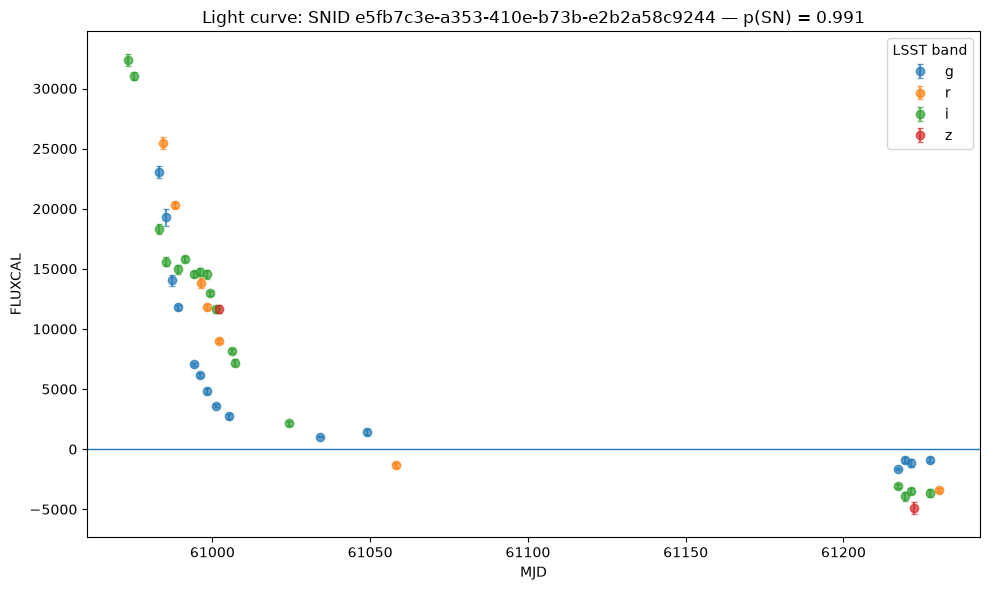

In [66]:
plot_lightcurve(
    lc_df,
    snid=str(head_row["SNID"]),
    p_sn=float(candidate["p_SN"]),
)

In [67]:
def plot_candidate_from_row(candidate_row, head_data, phot_data):
    head_row, lc = get_lightcurve_by_index(
        candidate_row["object_index"],
        head_data,
        phot_data,
    )

    lc_df = lightcurve_to_dataframe(lc)

    plot_lightcurve(
        lc_df,
        snid=str(head_row["SNID"]),
        p_sn=float(candidate_row["p_SN"]),
    )

    return lc_df

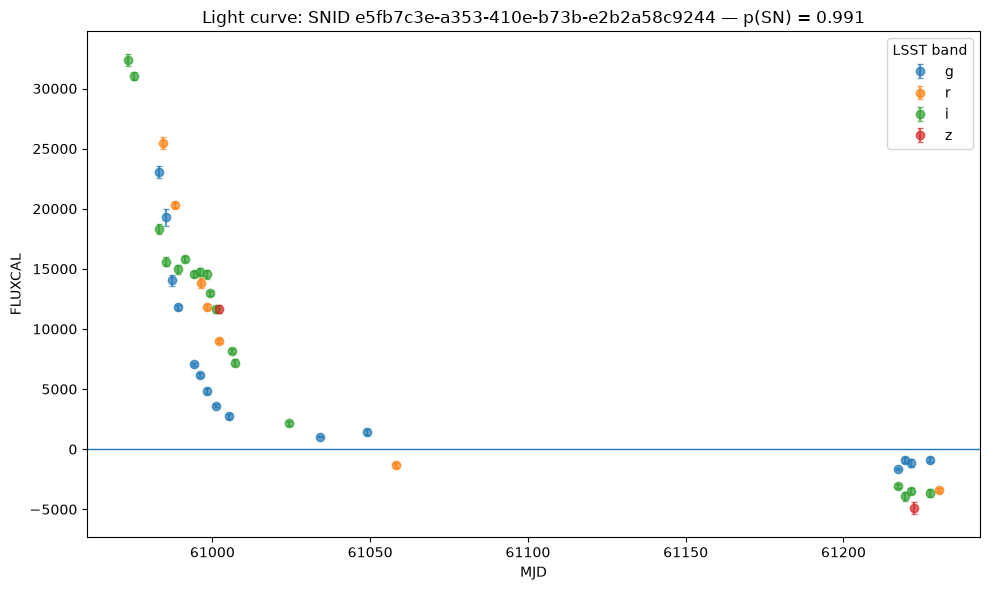

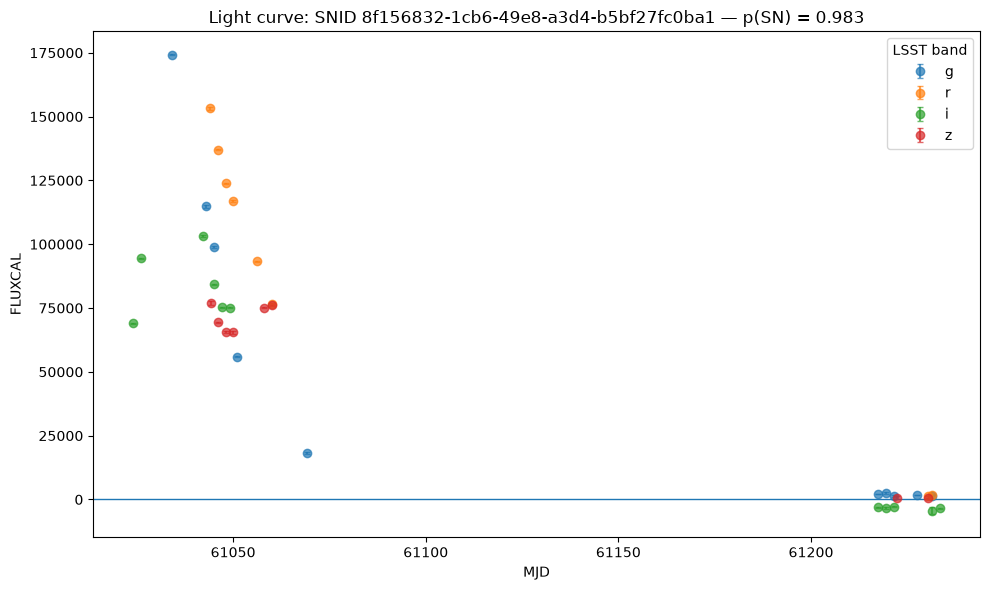

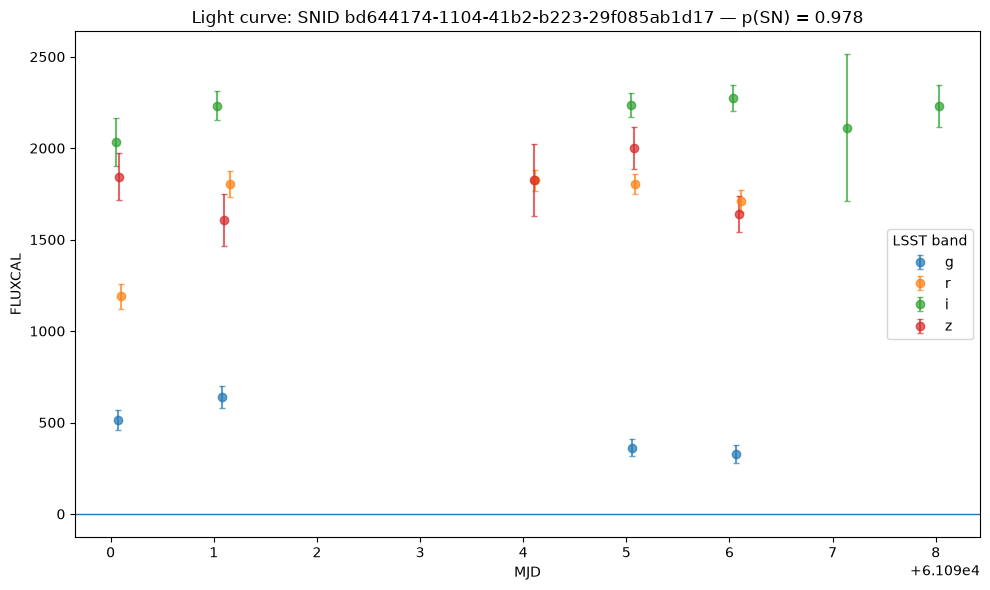

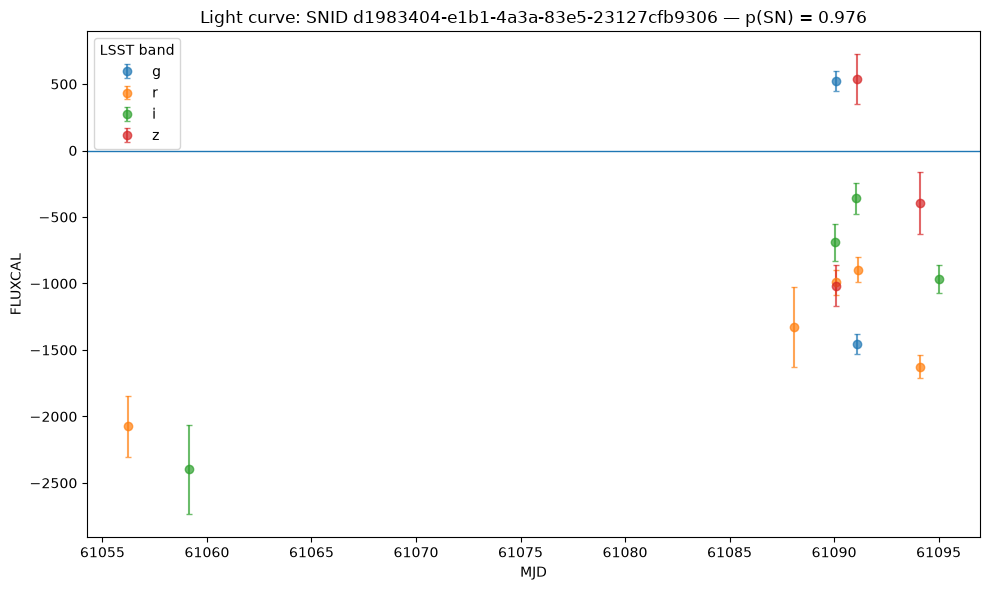

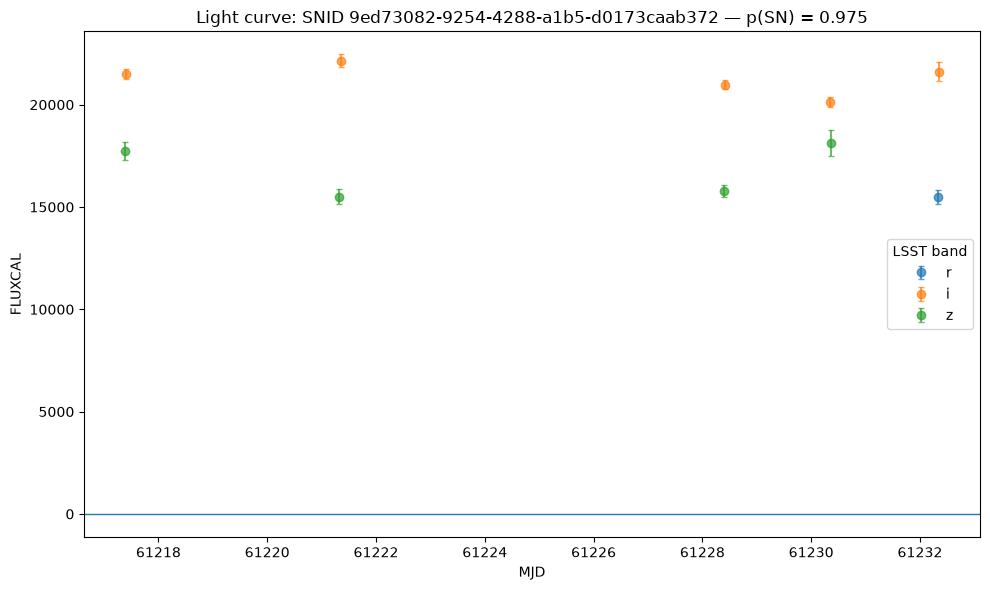

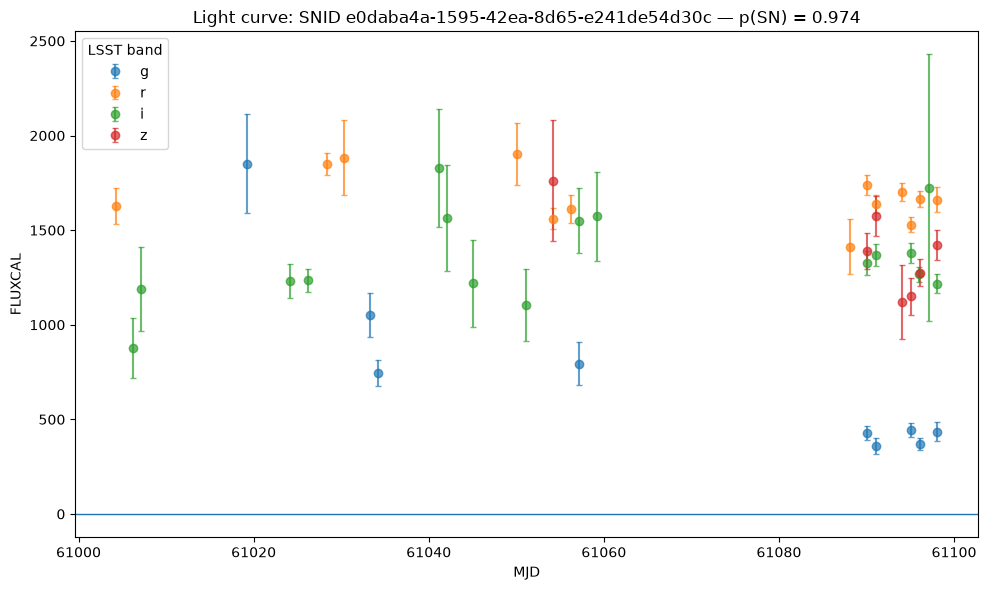

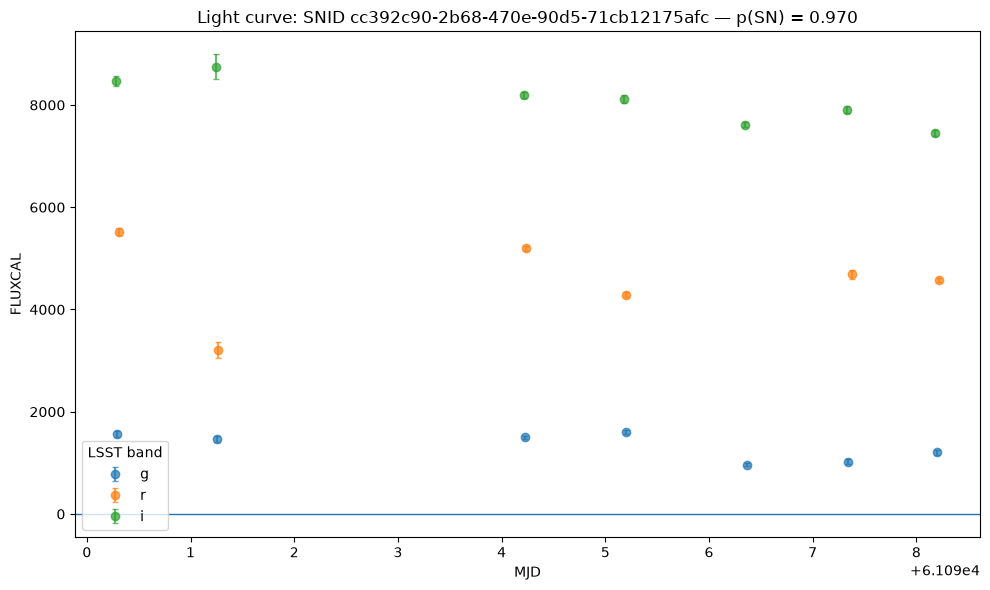

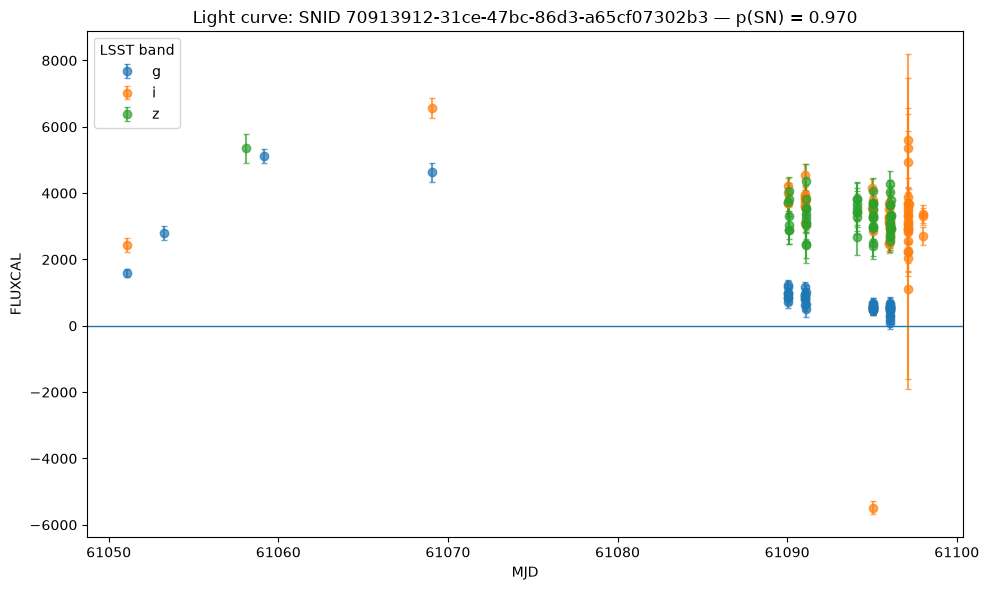

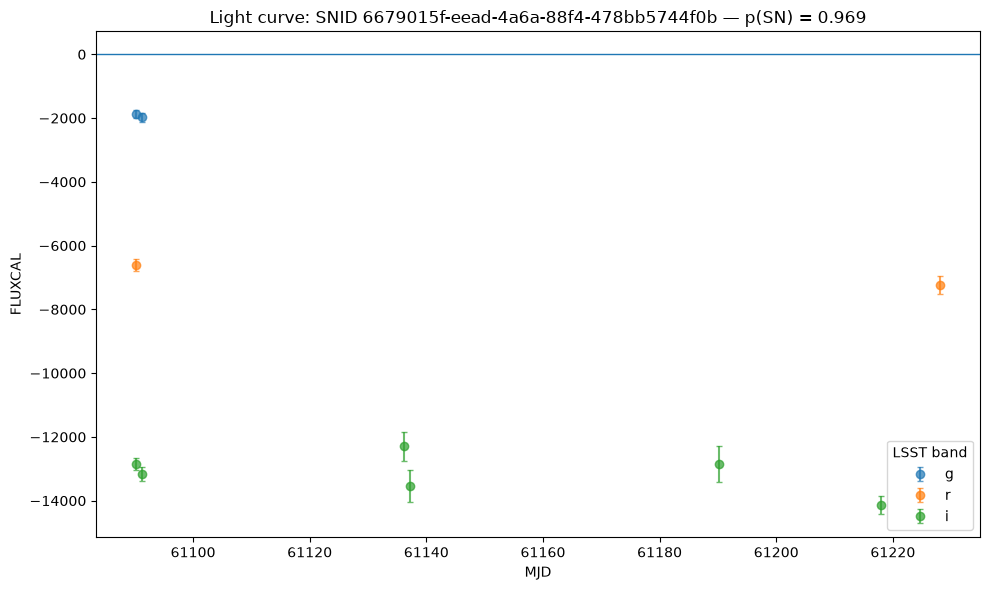

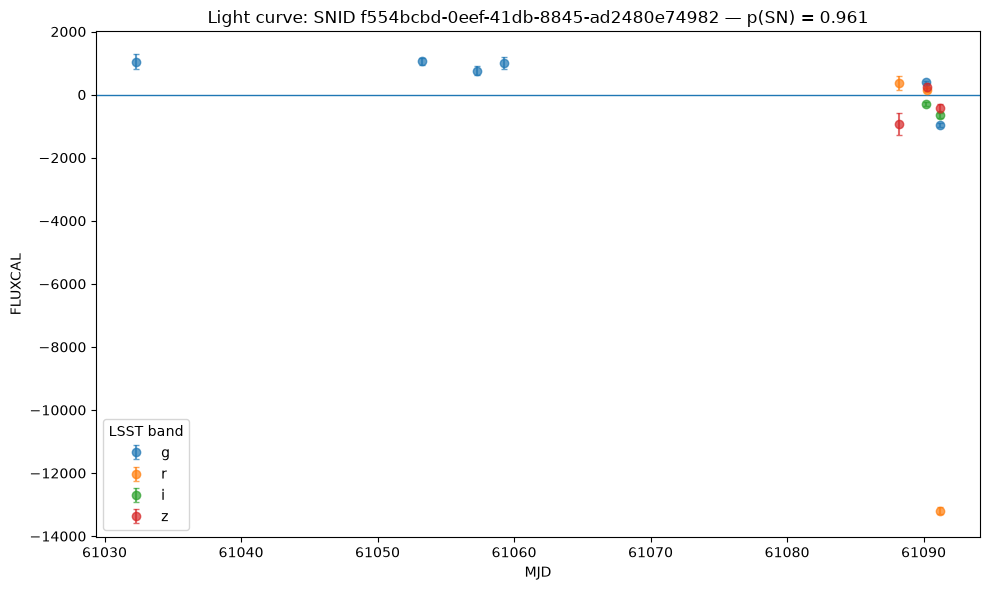

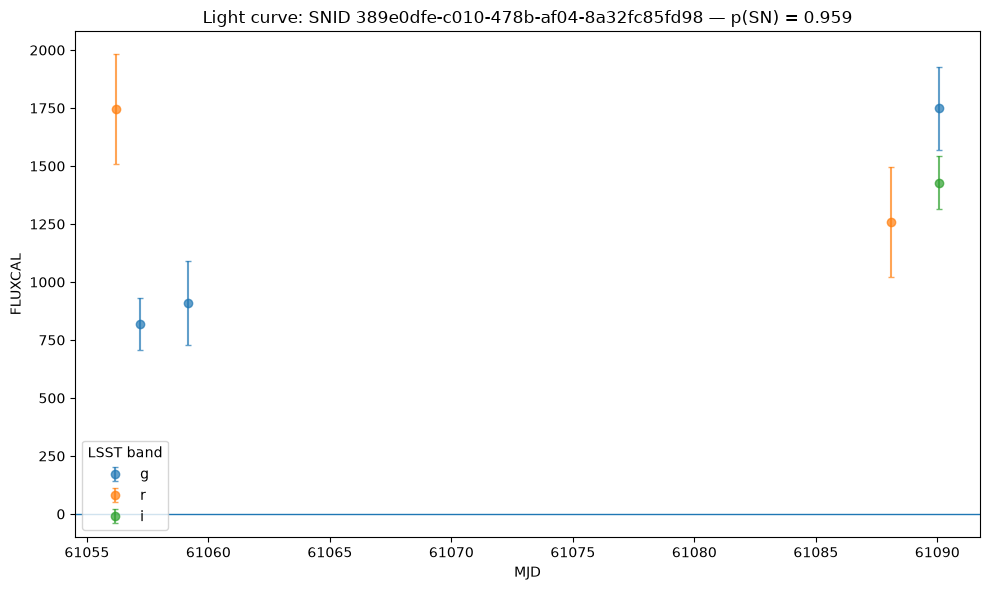

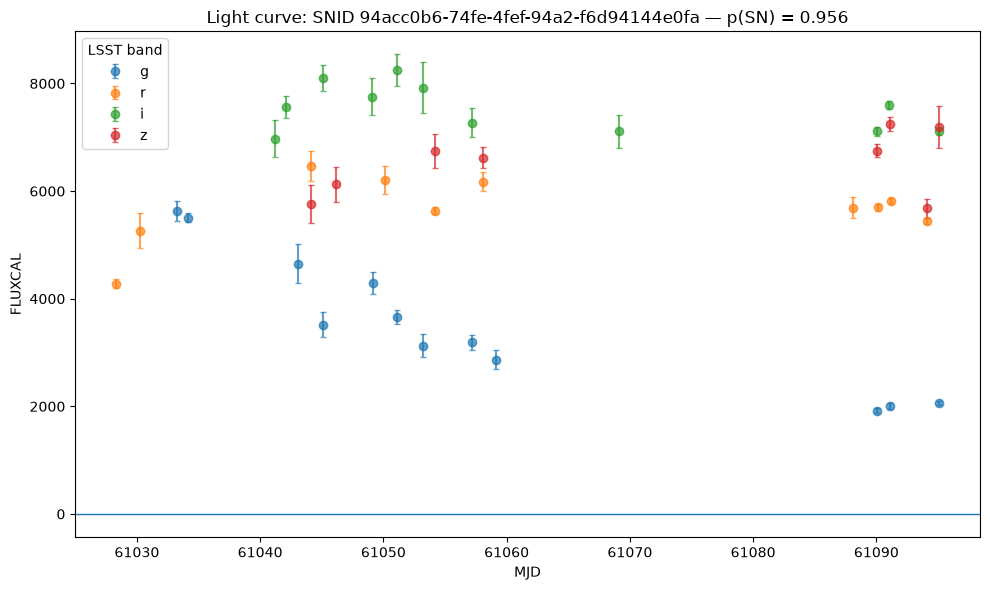

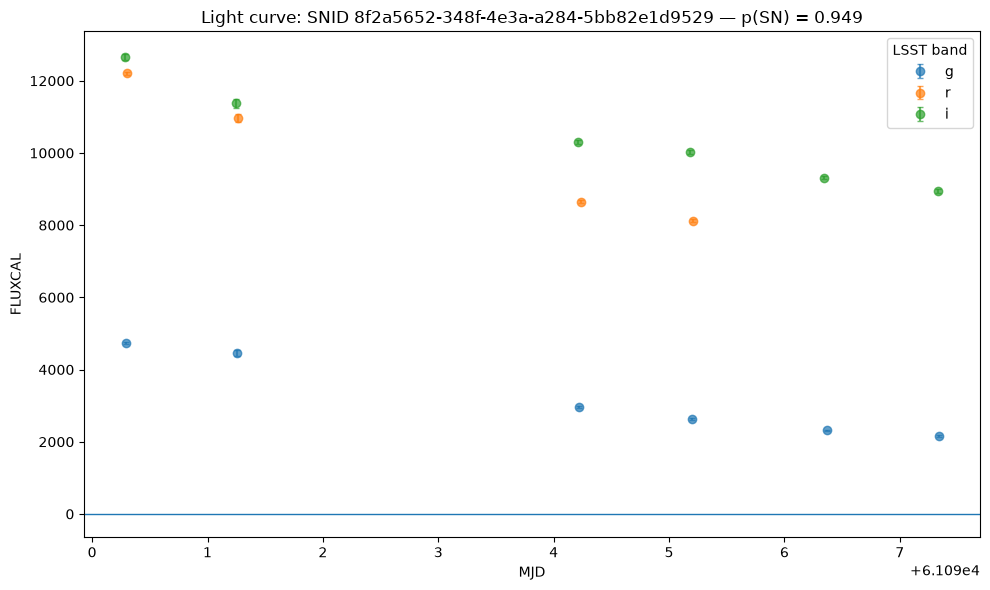

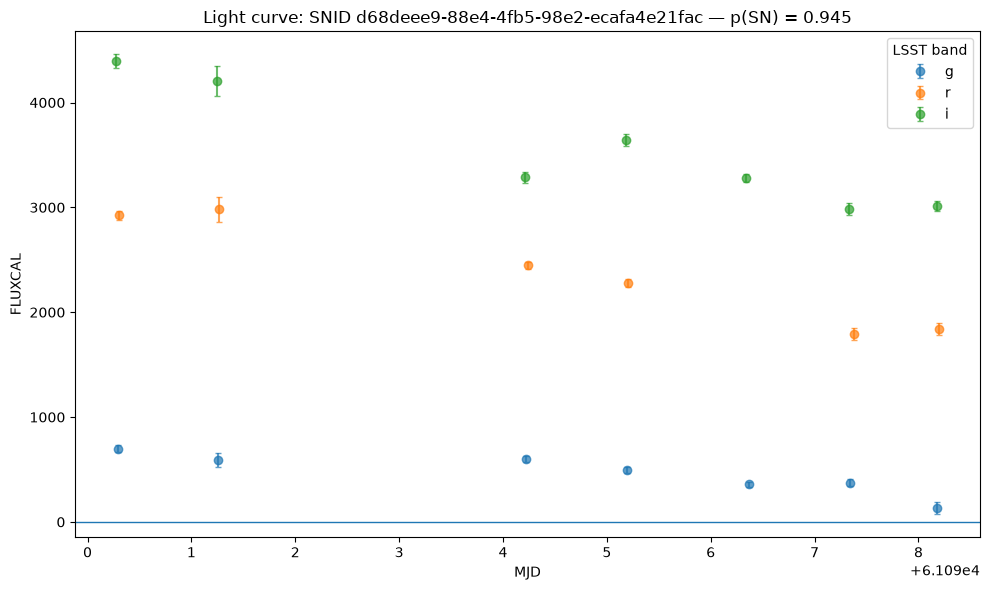

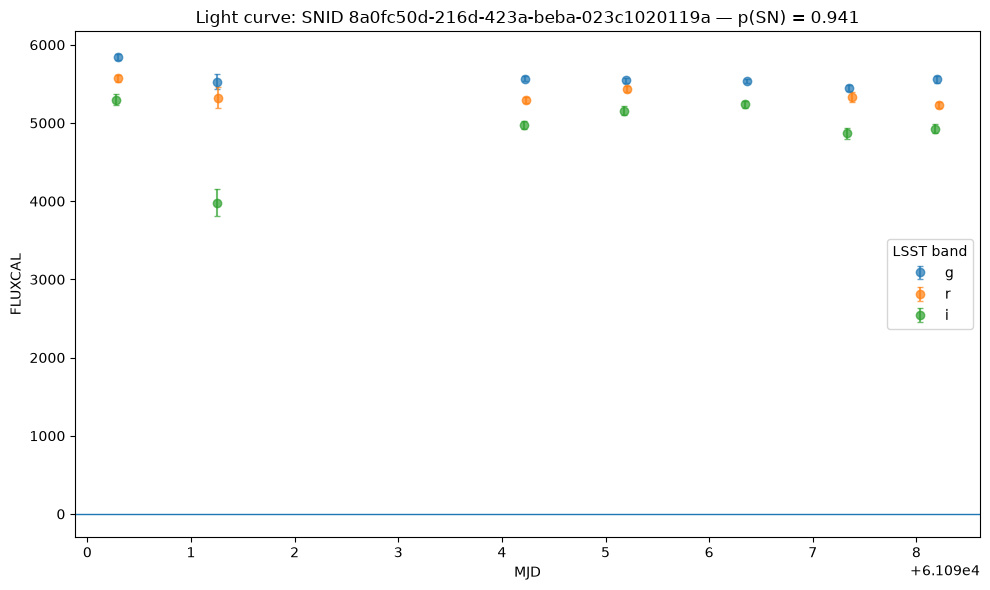

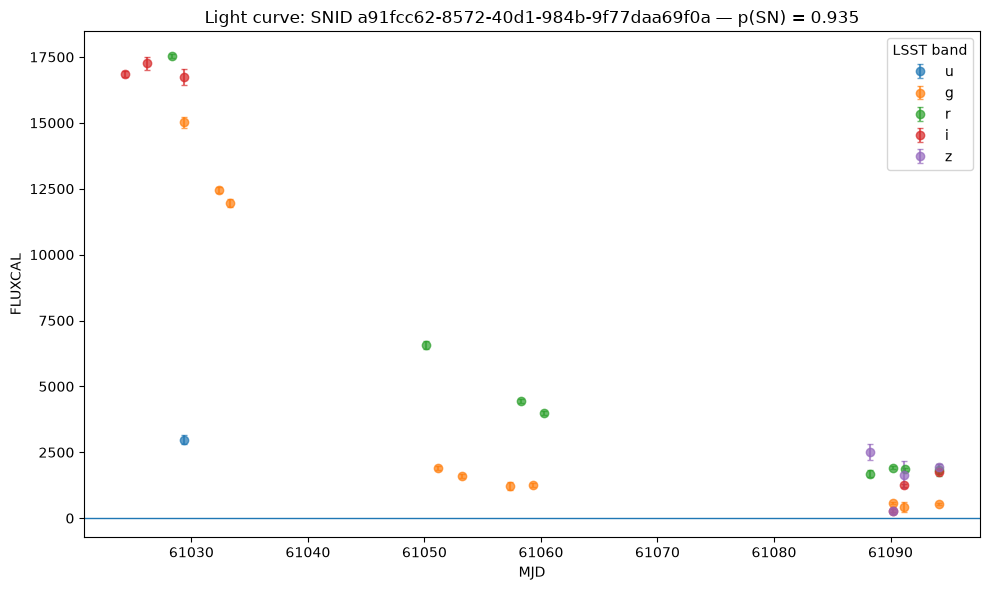

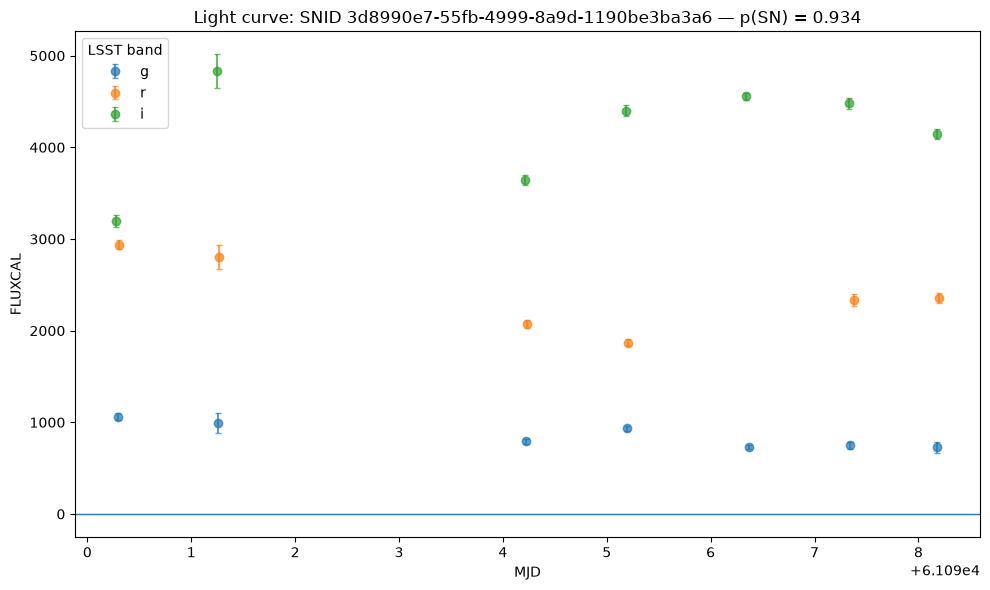

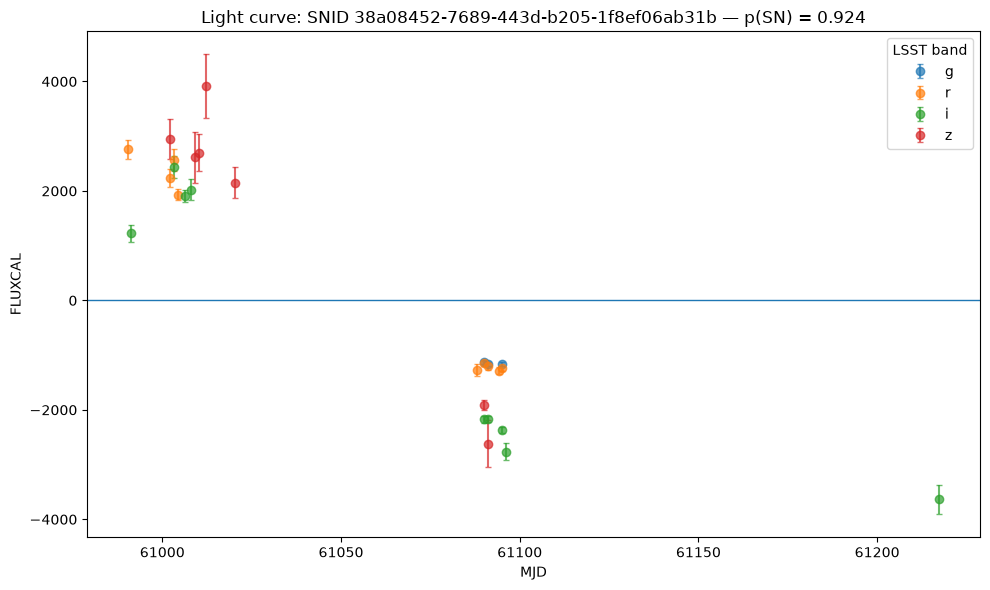

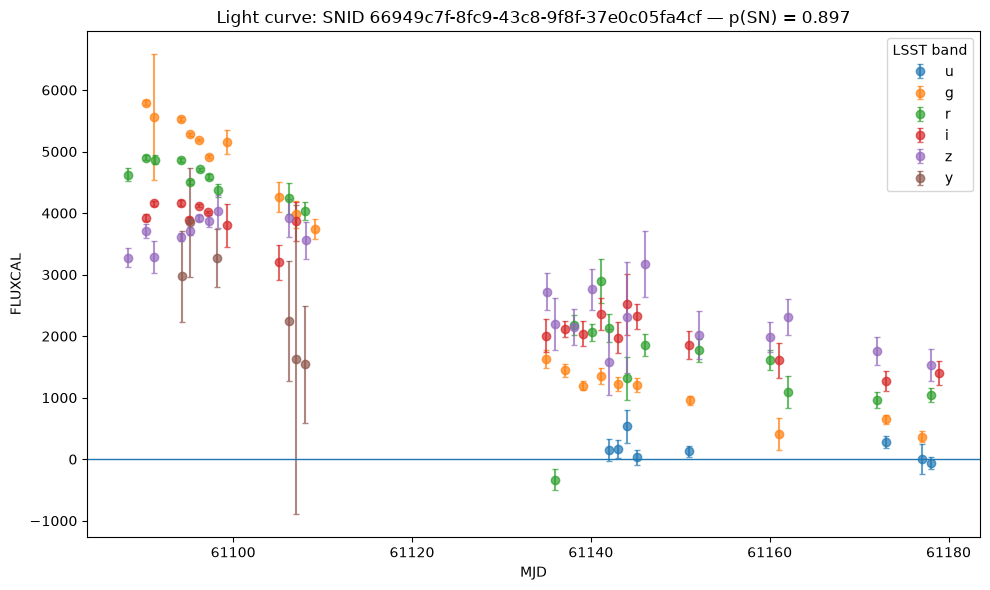

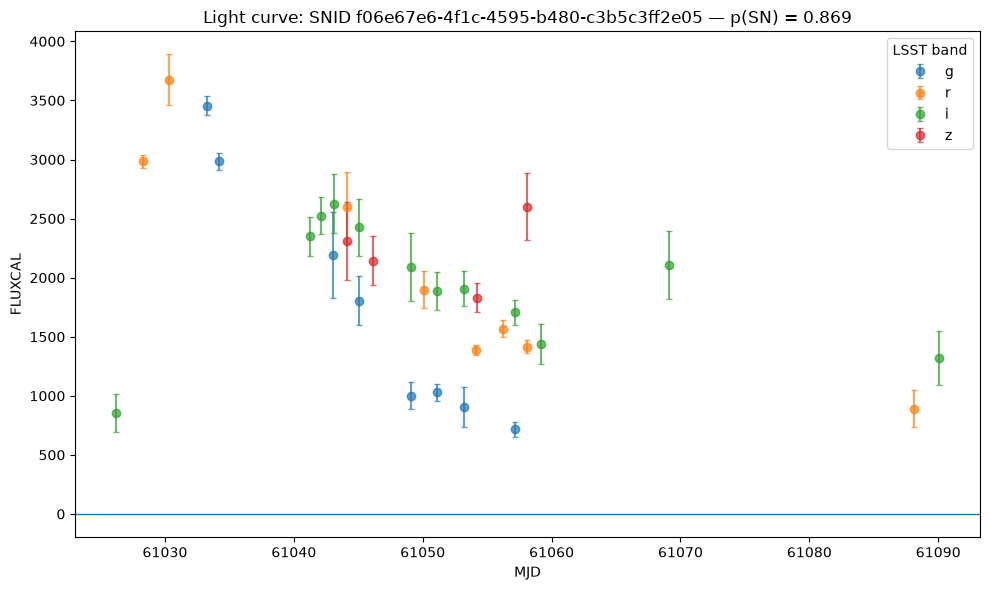

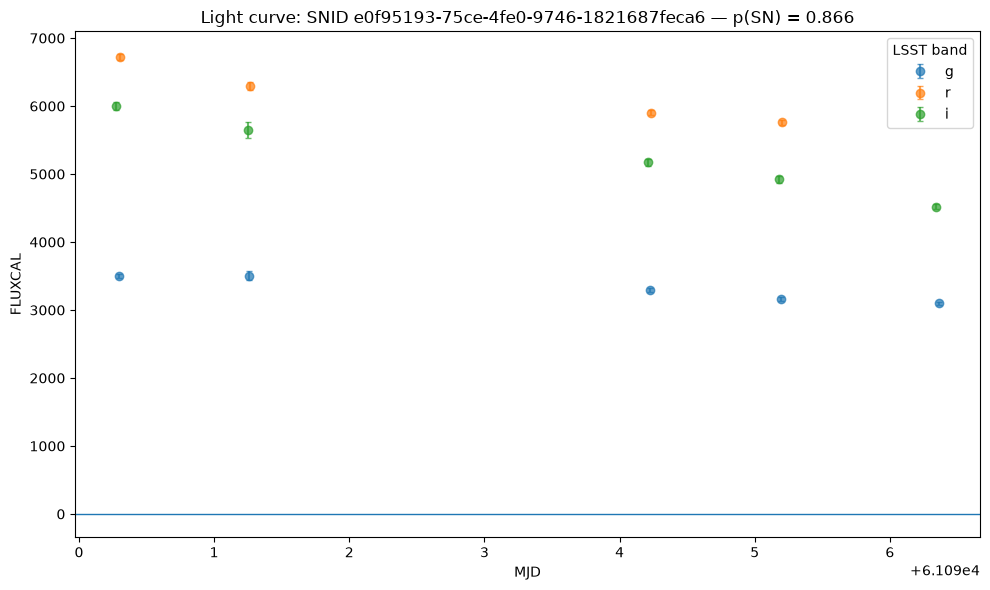

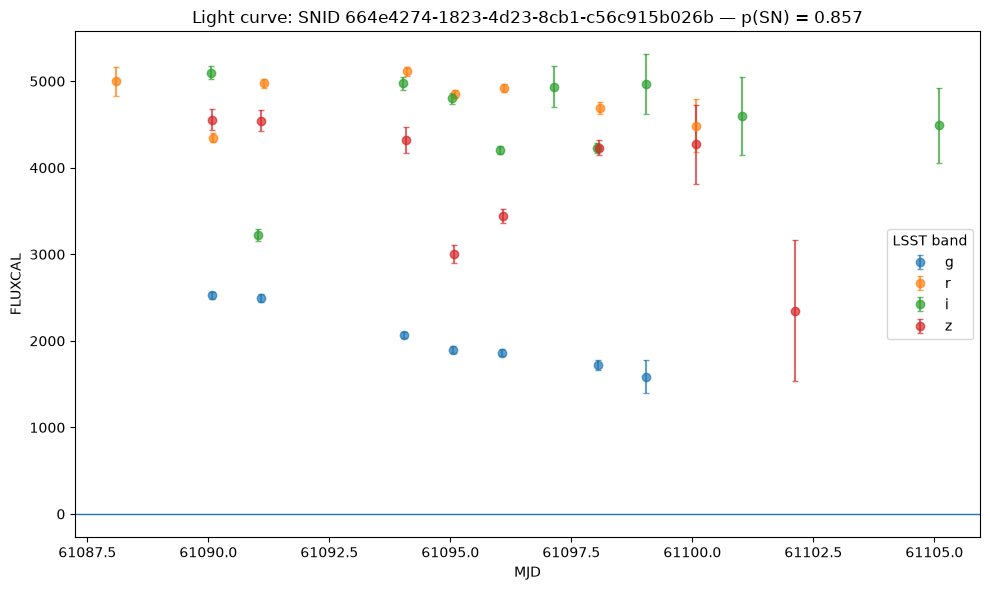

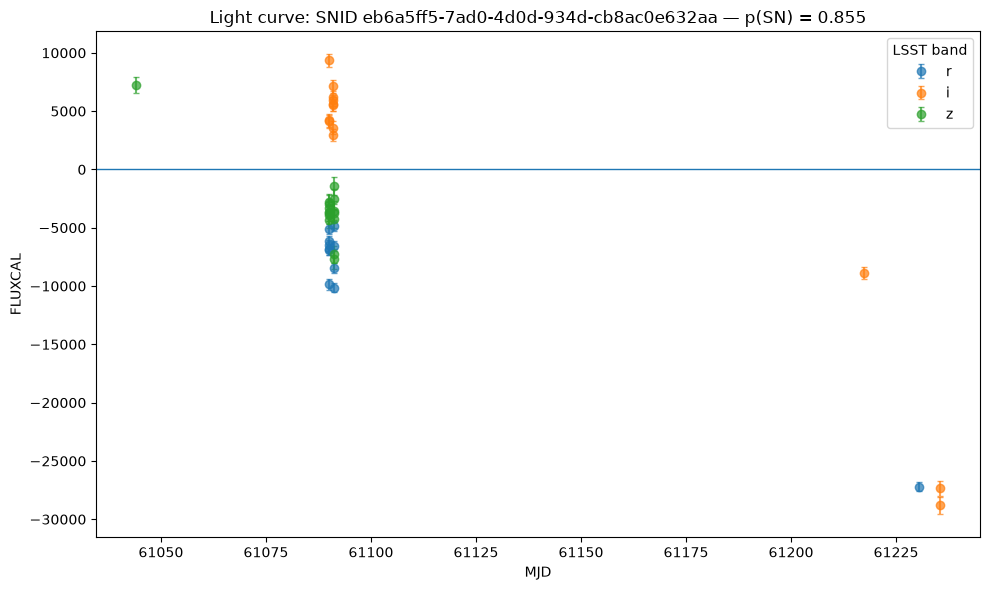

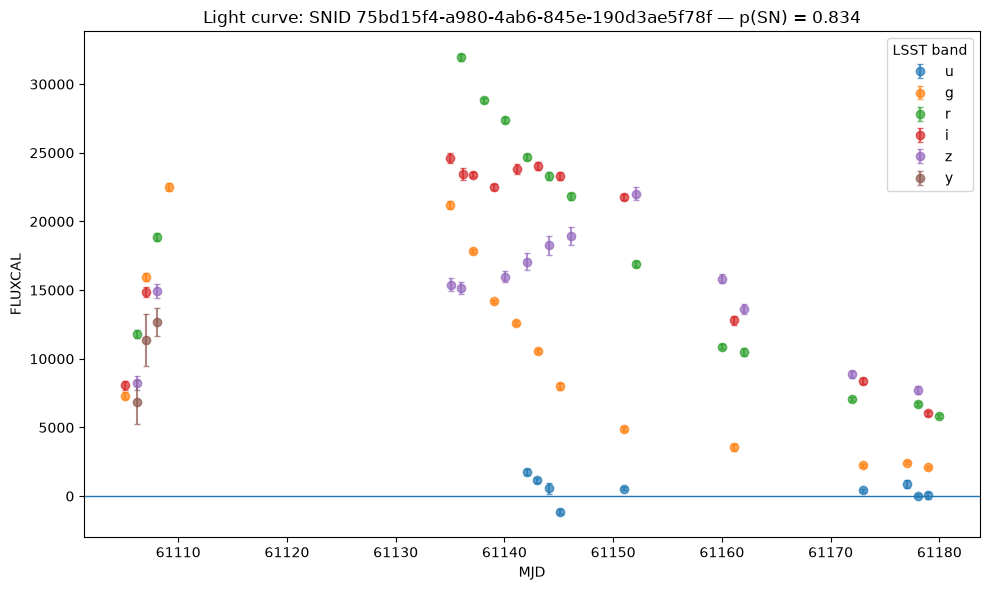

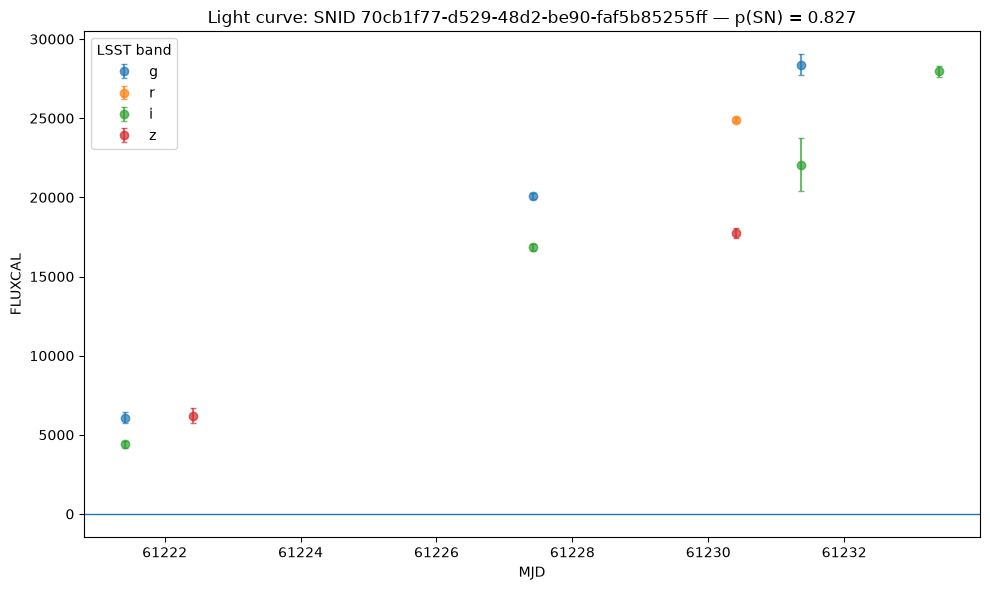

In [70]:
top_candidates = (
    cut_strict
    .sort_values("p_SN", ascending=False)
    .head(25)
)

for _, candidate_row in top_candidates.iterrows():
    _ = plot_candidate_from_row(
        candidate_row,
        head_data,
        phot_data,
    )